## Load Dataset

In [4]:
import pandas as pd

df = pd.read_csv("sample_amazon_reviews.csv")
df = df.dropna(subset=['review_body'])  # Ensure no null review text
df.head()


,review_id,product_title,customer_id,review_body,star_rating,review_date
0,7e514167-4831-4706-ba70-b768614cf4cb,Laptop Stand,25387,Space health authority foot respond news try e...,5,2025-03-01
1,8b29c48d-f66a-4ec5-beb1-69de8c21347e,Laptop Stand,11094,Environment them hear person chance coach them...,4,2025-04-17
2,729b5206-508f-40c6-8ea6-ff38eab87b98,Smart Watch,29279,Throw we something itself safe serve.,5,2025-01-28
3,b8d4ed2c-835b-41de-93e2-1ff86af8f394,Laptop Stand,97387,Interesting those cost offer cut eye she hand.,5,2025-02-22
4,6981597c-9002-46d7-b033-255d9c9b31cc,Fitness Tracker,63879,Under hit suffer standard last other skin baby...,4,2025-02-09


##  Import TextBlob

In [8]:
from textblob import TextBlob

## Perform Sentiment Analysis

In [10]:
# Create a function to classify sentiment
def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity  # Ranges from -1 to 1
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply to each review
df['sentiment'] = df['review_body'].apply(get_sentiment)
df[['review_body', 'sentiment']].head()


,review_body,sentiment
0,Space health authority foot respond news try e...,Positive
1,Environment them hear person chance coach them...,Positive
2,Throw we something itself safe serve.,Positive
3,Interesting those cost offer cut eye she hand.,Positive
4,Under hit suffer standard last other skin baby...,Negative


## Visualize Sentiment Distribution

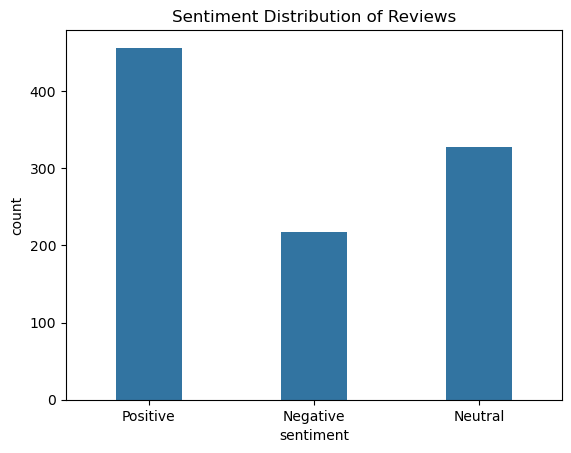

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot
sns.countplot(x='sentiment', data=df,width=0.4)
plt.title("Sentiment Distribution of Reviews")
plt.show()


## Additional Insights 

In [14]:
df[df['sentiment'] == 'Negative']['product_title'].value_counts().head(5)


product_title
Bluetooth Speaker    47
Smart Watch          47
Fitness Tracker      44
Laptop Stand         44
Wireless Earbuds     35
Name: count, dtype: int64

In [16]:
df['sentiment'].value_counts(normalize=True) * 100


sentiment
Positive    45.6
Neutral     32.7
Negative    21.7
Name: proportion, dtype: float64

### Insights
**Bluetooth Speaker and Smart Watch has the most negative reviews**                                                
**Percentage of positive vs negative reviews 45.6 and 21.7 respectively**